# Word Analysis Pilot
This notebook loads the V2 gender-extracted dataset and runs mini pilots on word association

In [2]:
import pandas as pd
import spacy
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

nlp = spacy.load("en_core_web_sm")

# Load the gender-extracted dataset
df = pd.read_csv('../../data/snippets/total_snippets_with_gender_v2.csv')

# We focus on clearly attributed Male and Female rows for this analysis
BINARY = ['Male', 'Female']
df_binary = df[df['Assigned_Gender'].isin(BINARY)].copy()

print(f"Male snippets: {(df_binary['Assigned_Gender']=='Male').sum()}")
print(f"Female snippets: {(df_binary['Assigned_Gender']=='Female').sum()}")
print(f"Total for analysis: {len(df_binary)}")


Male snippets: 1181
Female snippets: 373
Total for analysis: 1554


In [3]:
def extract_words_near_keyword(row):
    """Extracts adjectives, nouns, and verbs within a 30-token window of the opium keyword."""
    text = str(row['Snippet'])
    keyword = str(row['Keyword']).lower()
    doc = nlp(text)
    
    kw_token = next((t for t in doc if keyword in t.lemma_.lower() and t.pos_ != 'PROPN'), None)
    if not kw_token:
        return {'ADJ': [], 'NOUN': [], 'VERB': []}
    
    window = 30
    start = max(0, kw_token.i - window)
    end = min(len(doc), kw_token.i + window)
    
    words = {'ADJ': [], 'NOUN': [], 'VERB': []}
    for i in range(start, end):
        if len(doc[i].text) > 3 and doc[i].is_alpha and not doc[i].is_stop:
            pos = doc[i].pos_
            if pos in ['ADJ', 'NOUN', 'VERB']:
                words[pos].append(doc[i].lemma_.lower())
    return words

print("Extracting words...")
df_binary['Words'] = df_binary.apply(extract_words_near_keyword, axis=1)

gender_words = {
    'Male': {'ADJ': Counter(), 'NOUN': Counter(), 'VERB': Counter()},
    'Female': {'ADJ': Counter(), 'NOUN': Counter(), 'VERB': Counter()}
}

for _, row in df_binary.iterrows():
    g = row['Assigned_Gender']
    for pos in ['ADJ', 'NOUN', 'VERB']:
        gender_words[g][pos].update(row['Words'][pos])

print("Extraction complete.")


Extracting words...
Extraction complete.


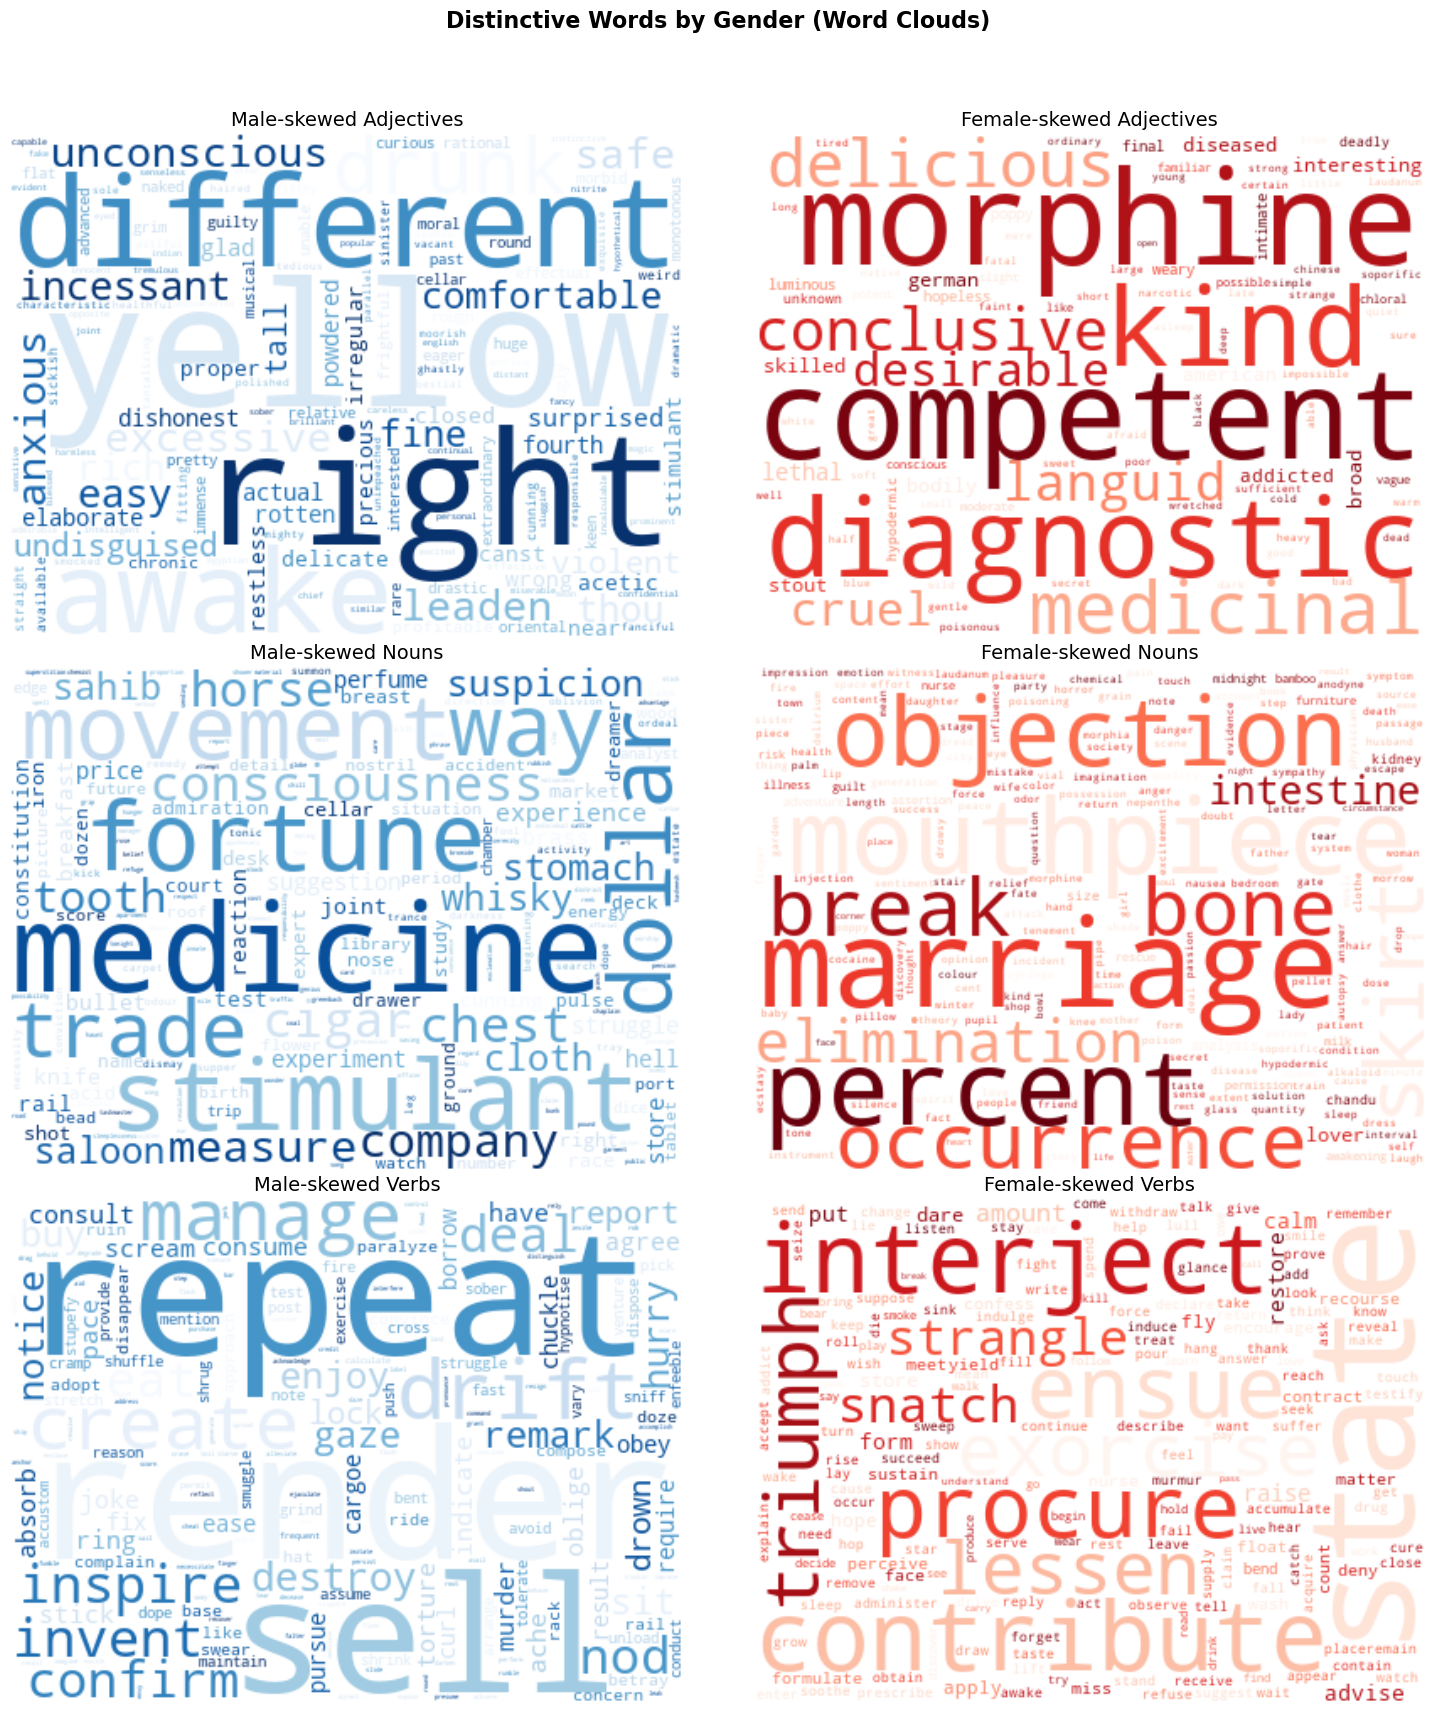

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

def get_distinctive_words(male_counter, female_counter, min_count=3):
    all_words = set(list(male_counter.keys()) + list(female_counter.keys()))
    male_total = sum(male_counter.values()) or 1
    female_total = sum(female_counter.values()) or 1
    
    distinctly_male = {}
    distinctly_female = {}
    
    for w in all_words:
        m_freq = male_counter[w] / male_total
        f_freq = female_counter[w] / female_total
        
        if male_counter[w] >= min_count:
            distinctly_male[w] = m_freq / max(f_freq, 1e-6)
        if female_counter[w] >= min_count:
            distinctly_female[w] = f_freq / max(m_freq, 1e-6)
            
    return distinctly_male, distinctly_female

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Distinctive Words by Gender (Word Clouds)', fontsize=16, fontweight='bold')

pos_labels = ['ADJ', 'NOUN', 'VERB']
pos_titles = ['Adjectives', 'Nouns', 'Verbs']

for i, pos in enumerate(pos_labels):
    m_distinct, f_distinct = get_distinctive_words(gender_words['Male'][pos], gender_words['Female'][pos])
    
    wc_m = WordCloud(width=400, height=300, background_color='white', colormap='Blues').generate_from_frequencies(m_distinct)
    axes[i, 0].imshow(wc_m, interpolation='bilinear')
    axes[i, 0].set_title(f'Male-skewed {pos_titles[i]}', fontsize=14)
    axes[i, 0].axis('off')
    
    wc_f = WordCloud(width=400, height=300, background_color='white', colormap='Reds').generate_from_frequencies(f_distinct)
    axes[i, 1].imshow(wc_f, interpolation='bilinear')
    axes[i, 1].set_title(f'Female-skewed {pos_titles[i]}', fontsize=14)
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../../data/snippets/wordclouds_by_gender.png', dpi=150)
plt.show()

print("Word clouds saved to ../../data/snippets/wordclouds_by_gender.png")


- yellow, repeat??

In [5]:
def show_top_raw_words(gender_words_dict, pos='ADJ', top_n=20):
    """
    Displays the top N most frequent words for Male and Female based on raw counts.
    pos can be 'ADJ', 'NOUN', or 'VERB'.
    """
    print(f"--- Top {top_n} {pos} (Raw Counts) ---")
    
    male_top = gender_words_dict['Male'][pos].most_common(top_n)
    female_top = gender_words_dict['Female'][pos].most_common(top_n)
    
    # Pad with empty strings if one list is shorter than the other
    max_len = max(len(male_top), len(female_top))
    male_display = [f"{w} ({c})" for w, c in male_top] + [""] * (max_len - len(male_top))
    female_display = [f"{w} ({c})" for w, c in female_top] + [""] * (max_len - len(female_top))
    
    # Create a nice DataFrame for display side-by-side
    df_raw = pd.DataFrame({
        f"Male {pos}": male_display,
        f"Female {pos}": female_display
    })
    
    display(df_raw)

In [6]:
show_top_raw_words(gender_words, pos='ADJ', top_n=15)

--- Top 15 ADJ (Raw Counts) ---


,Male ADJ,Female ADJ
0,little (80),good (31)
1,good (60),little (22)
2,narcotic (54),poor (15)
3,great (47),small (14)
4,white (34),narcotic (13)
5,poor (32),great (13)
6,strong (30),hypodermic (12)
7,long (30),long (11)
8,small (30),strong (11)
9,heavy (29),certain (10)


In [7]:
def show_snippets_for_word(df, target_word, pos='ADJ', gender=None, num_samples=5):
    """
    Prints examples of snippets where the target_word was extracted.
    - target_word: The word you are curious about (e.g., 'cruel')
    - pos: The part of speech ('ADJ', 'NOUN', or 'VERB')
    - gender: Optional filter ('Male' or 'Female')
    """
    print(f"--- Snippets containing the {pos} '{target_word}' ---")
    
    # Filter by gender if specified
    if gender:
        df_sub = df[df['Assigned_Gender'] == gender]
    else:
        df_sub = df
        
    # Find rows where the target_word is in the extracted words for the given POS
    def contains_word(words_dict):
        if isinstance(words_dict, dict) and pos in words_dict:
            return target_word.lower() in words_dict[pos]
        return False
        
    mask = df_sub['Words'].apply(contains_word)
    matched_df = df_sub[mask]
    
    print(f"Total occurrences found: {len(matched_df)}\n")
    
    # Print the examples
    for idx, row in matched_df.head(num_samples).iterrows():
        print(f"[{row['Assigned_Gender']}] - Keyword: {row['Keyword']}")
        print(f"Snippet: {row['Snippet']}")
        print("-" * 80)

In [8]:
show_snippets_for_word(df_binary, target_word='yellow', pos='ADJ', gender='Male')

--- Snippets containing the ADJ 'yellow' ---
Total occurrences found: 15

[Male] - Keyword: opium
Snippet: his head buried in his arms, a sailor sprawled over a table, and by the tawdrily painted bar that ran across one complete side stood two haggard women, mocking an old man who was brushing the sleeves of his coat with an expression of disgust. “He thinks he’s got red ants on him,” laughed one of them, as Dorian passed by. The man looked at her in terror and began to whimper. At the end of the room there was a little staircase, leading to a darkened chamber. As Dorian hurried up its three rickety steps, the heavy odour of opium met him. He heaved a deep breath, and his nostrils quivered with pleasure. When he entered, a young man with smooth yellow hair, who was bending over a lamp lighting a long thin pipe, looked up at him and nodded in a hesitating manner. “You here, Adrian?” muttered Dorian. “Where else should I be?” he answered, listlessly. “None of the chaps will speak to me n

In [9]:
show_snippets_for_word(df_binary, target_word='repeat', pos='VERB', gender='Male')

--- Snippets containing the VERB 'repeat' ---
Total occurrences found: 14

[Male] - Keyword: heroin
Snippet: all, Walter,” he said as we swung aboard an uptown car, “I want to stop at the laboratory.” In his den, which had been the scene of so many triumphs, Kennedy began a hasty examination of the tablets, powdering one and testing it with one chemical after another. “What are they?” I asked at length when he seemed to have found the right reaction which gave him the clue. “Happy dust,” he answered briefly. “Happy dust?” I repeated, looking at him a moment in doubt as to whether he was joking or serious. “What is that?” “The Tenderloin name for heroin —a comparatively new derivative of morphine. It is really morphine treated with acetic acid which renders it more powerful than morphine alone.” “How do they take them? What’s the effect?” I asked. “The person who uses heroin usually powders the tablets and snuffs the powder up the nose,” he answered. “In a short time, perhaps only two o